In [55]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

crime_data = pd.read_csv('../data/raw_2021-2024.csv')

crime_data = crime_data.dropna(subset=['Latitude', 'Longitude'])

neighborhoods = gpd.read_file('../data/neighborhoods/Neighborhoods.shp')

C:\Users\User\AppData\Local\Temp\ipykernel_13860\1108208656.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_data = pd.read_csv('../data/raw_2021-2024.csv')


In [28]:
neighborhood_pop = pd.read_csv('../data/neighborhoods/neighborhood_populations.csv')

In [3]:
# Aggregate crime data by neighborhood
crime_counts = crime_data.groupby("Neighborhood")["IncidentNum"].count().reset_index(name="CrimeCount")

In [57]:
# Merge crime data with the shapefile
neighborhoods_with_crime = neighborhoods.merge(crime_counts, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_crime = neighborhoods_with_crime.merge(neighborhood_pop, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_crime["CrimeCount"] = neighborhoods_with_crime["CrimeCount"].fillna(0)
# neighborhoods_with_crime = neighborhoods_with_crime[~neighborhoods_with_crime['NHD_NAME'].isin(neighborhoods_to_drop)]
# neighborhoods_with_crime = neighborhoods_with_crime[neighborhoods_with_crime['Population'] >= 400]
neighborhoods_with_crime["PopCrime"] = neighborhoods_with_crime["CrimeCount"]/neighborhoods_with_crime["Population"]

# remove neighborhoods with less than 400 residents to not skew data
neighborhoods_with_crime['PopCrime'] = np.where(neighborhoods_with_crime['Population'] < 400, 0, neighborhoods_with_crime['PopCrime'])

In [51]:
print(neighborhoods_with_crime.head)

<bound method NDFrame.head of     NHD_NUM             NHD_NAME  ANGLE              NHD_NUMTXT NHD_NUM_ST  \
0        43           Franz Park    0.0           43 Franz Park       None   
1        29              Tiffany    0.0              29 Tiffany       None   
2        28    Botanical Heights    0.0    28 Botanical Heights       None   
3        40            Kings Oak    0.0            40 Kings Oak       None   
4        41           Cheltenham    0.0           41 Cheltenham       None   
..      ...                  ...    ...                     ...        ...   
83       75            Riverview    0.0            75 Riverview       None   
84       82          Forest Park    0.0          82 Forest Park       None   
85       47    DeBaliviere Place    0.0    47 DeBaliviere Place       None   
86       46  Skinker DeBaliviere    0.0  46 Skinker DeBaliviere       None   
87       35             Downtown    0.0             35 Downtown       None   

                                 

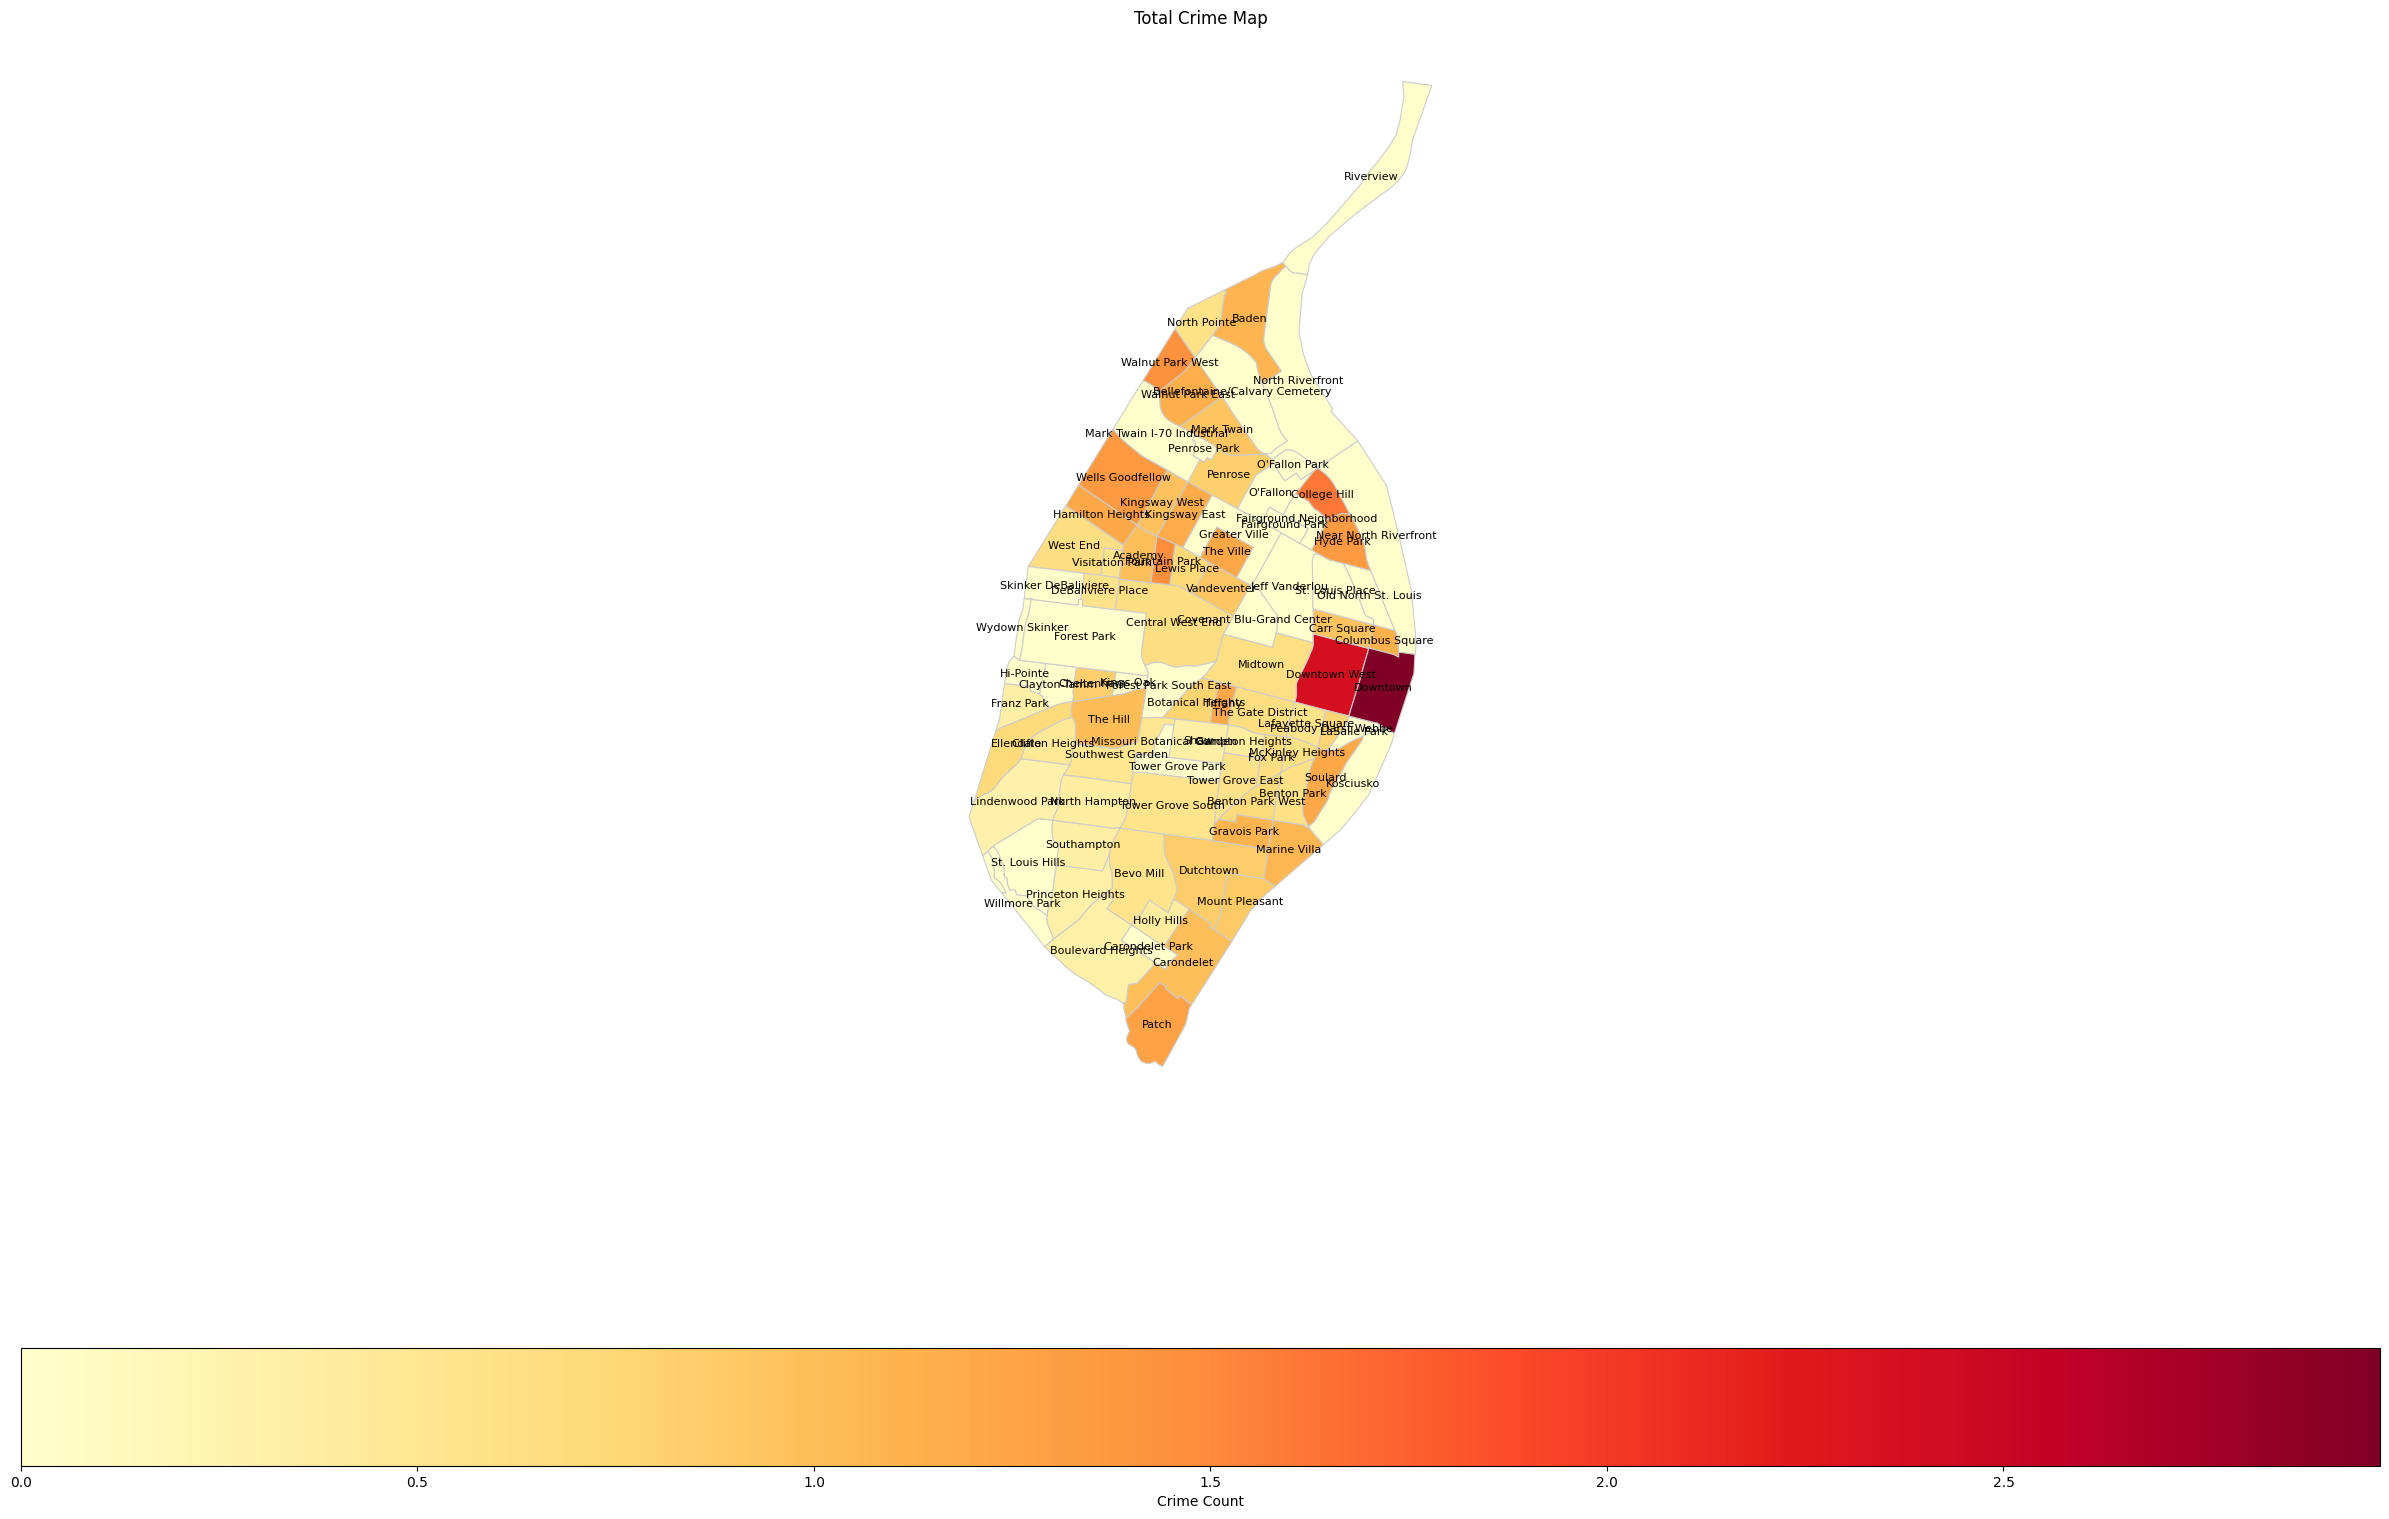

In [58]:
def create_chloropleth(dataframe, title):
    # Create the choropleth map
    fig, ax = plt.subplots(figsize=(24, 16))
    dataframe.plot(column="PopCrime", cmap="YlOrRd", linewidth=0.8, edgecolor="0.8", ax=ax, legend=True, legend_kwds={"label": "Crime Count", "orientation": "horizontal"})
    
    # Add neighborhood labels
    for idx, row in dataframe.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row["NHD_NAME"], fontsize=8, ha="center", va="center")
    
    ax.set_title(title)
    ax.axis("off")
    
    plt.tight_layout()
    plt.show()

create_chloropleth(neighborhoods_with_crime, "Total Crime Map")

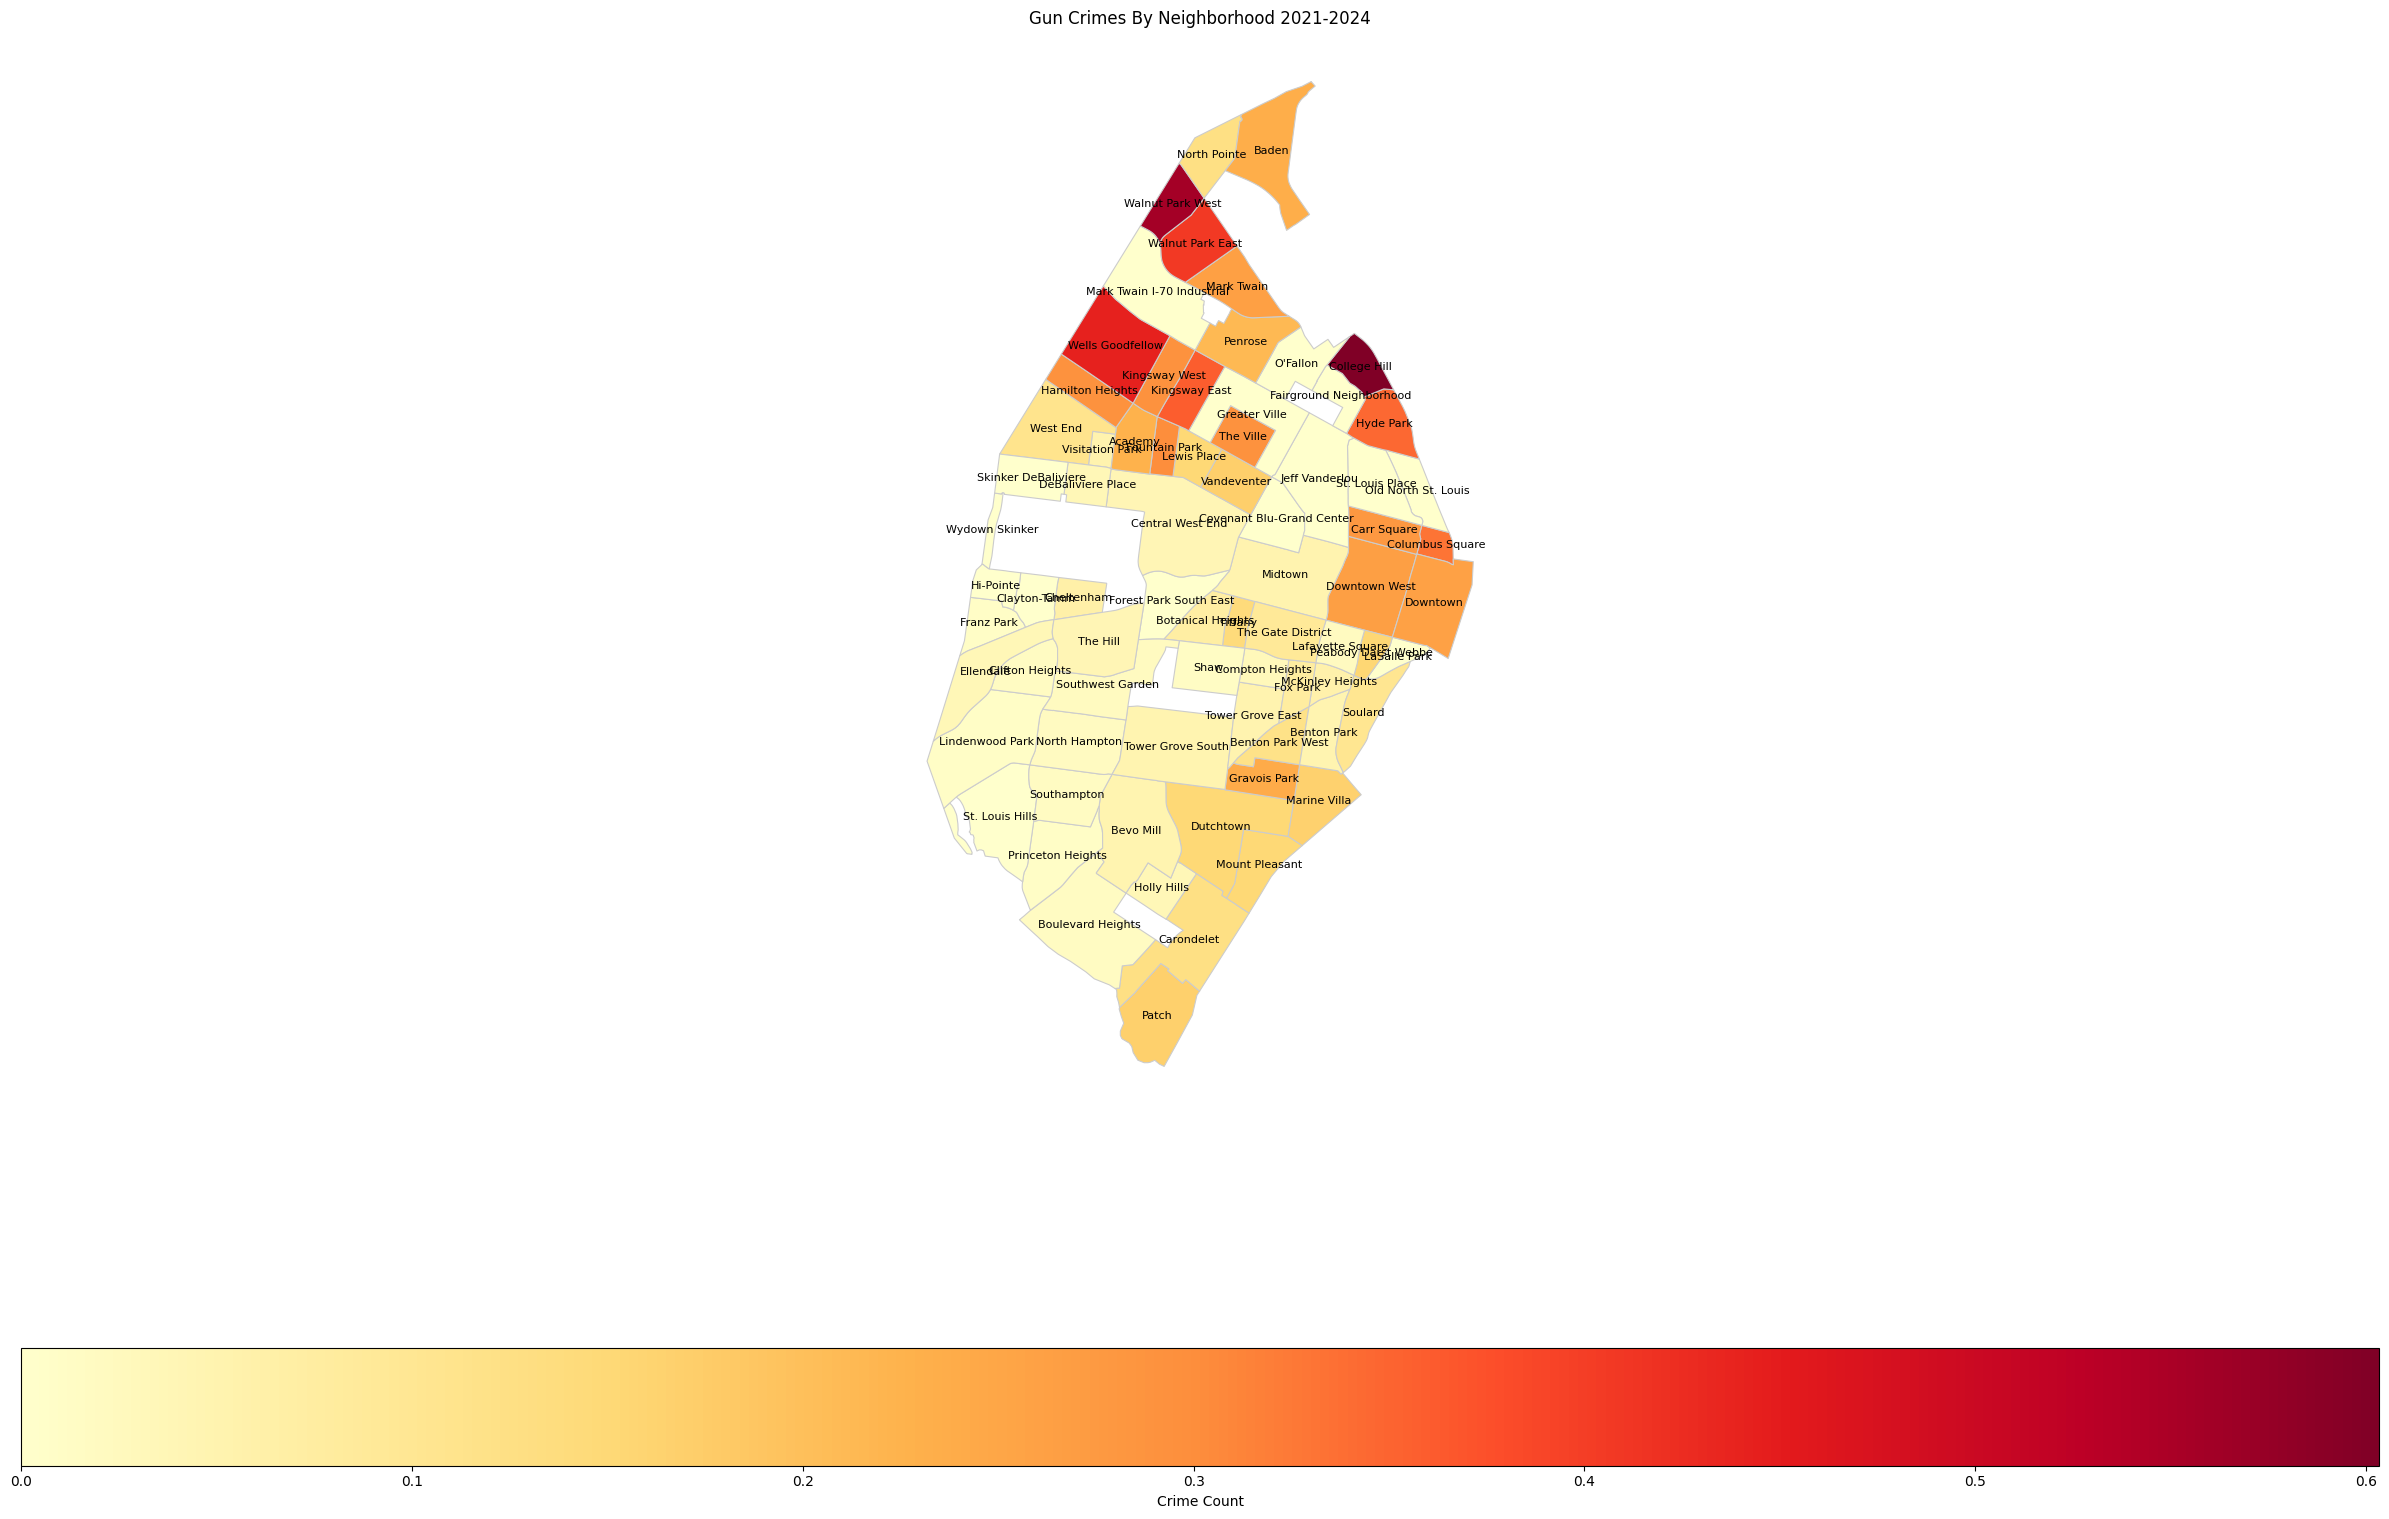

In [48]:
gun_crime_data = crime_data[crime_data['FirearmUsed'] == 'Yes']

gun_crime_counts = gun_crime_data.groupby("Neighborhood")["IncidentNum"].count().reset_index(name="CrimeCount")

neighborhoods_with_gun_crime = neighborhoods.merge(gun_crime_counts, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_gun_crime = neighborhoods_with_gun_crime.merge(neighborhood_pop, left_on="NHD_NAME", right_on="Neighborhood", how="left")

neighborhoods_with_gun_crime["CrimeCount"] = neighborhoods_with_gun_crime["CrimeCount"].fillna(0)
neighborhoods_with_gun_crime = neighborhoods_with_gun_crime[neighborhoods_with_gun_crime['Population'] >= 400]
neighborhoods_with_gun_crime["PopCrime"] = neighborhoods_with_gun_crime["CrimeCount"]/neighborhoods_with_gun_crime["Population"]

create_chloropleth(neighborhoods_with_gun_crime, "Gun Crimes By Neighborhood 2021-2024")